In [13]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
import seaborn as sns

Load Preprocessed Data

In [14]:
X_train, X_test, y_train, y_test = joblib.load('../outputs/processed_data.pkl')
print("Data loaded.")

Task was destroyed but it is pending!
task: <Task pending name='Task-1850' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-1851' coro=<Kernel.shell_main() running at /Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/joblib/numpy_pickle.py:170: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  shape_int64 = [unpickler.np.int64(x) for x in self.shape]
Task was destroyed but it is pending!
task: <Task pending name='Task-1851' coro=<Kernel.shell_main() running at /Users/syedrauf/fraud_detection_project/venv/lib/python3.1

Data loaded.


Train XGBoost

In [43]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=2,      # SMOTE handles balance, so set to 2s
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train, 
        eval_set=[(X_test, y_test)], 
        verbose=50)


[0]	validation_0-aucpr:0.42126


/Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:39:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-aucpr:0.72031
[100]	validation_0-aucpr:0.80890
[150]	validation_0-aucpr:0.79941
[199]	validation_0-aucpr:0.82315


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Evaluate


── Classification Report ──
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.26      0.88      0.40        98

    accuracy                           1.00     56962
   macro avg       0.63      0.94      0.70     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC:  0.9748
AUC-PR:   0.8239  ← key metric for imbalanced data


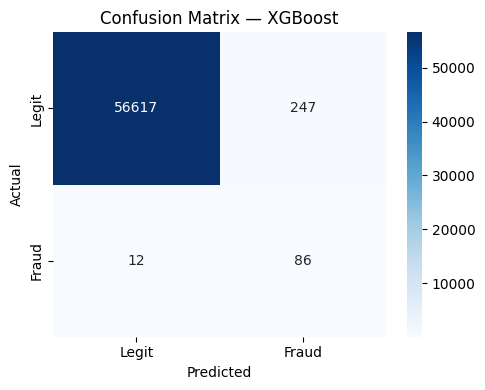

In [44]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud'],zero_division=0))

auc_roc = roc_auc_score(y_test, y_prob)
auc_pr  = average_precision_score(y_test, y_prob)
print(f"AUC-ROC:  {auc_roc:.4f}")
print(f"AUC-PR:   {auc_pr:.4f}  ← key metric for imbalanced data")

# ── 4. Confusion Matrix ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'], ax=ax)
ax.set_title('Confusion Matrix — XGBoost')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()

ROC Curve

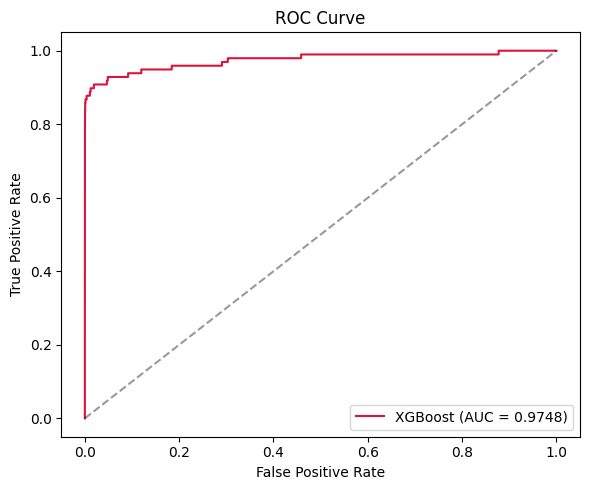

In [46]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, color='crimson', label=f'XGBoost (AUC = {auc_roc:.4f})')
ax.plot([0,1],[0,1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png', dpi=150)
plt.show()

Baseline: Isolation Forest (anomaly, no labels)

In [47]:
iso = IsolationForest(contamination=0.001, random_state=42, n_jobs=-1)
iso.fit(X_train)
iso_pred = iso.predict(X_test)
iso_pred_binary = (iso_pred == -1).astype(int)   # -1 = anomaly = fraud

print("\n── Isolation Forest (Baseline) ──")
print(classification_report(y_test, iso_pred_binary, target_names=['Legit', 'Fraud'],zero_division=0))


── Isolation Forest (Baseline) ──
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



Save Model

In [12]:
joblib.dump(xgb, '../outputs/xgb_model.pkl')
print("\n✅ Model saved to /outputs/xgb_model.pkl")


✅ Model saved to /outputs/xgb_model.pkl
